### Backtesting a simple moving average (MA) cross-over strategy, on Google data.

In [1]:
import os

import datetime   #Built-in Python module, useful for handling date/time data (often used in backtesting).
import pandas as pd
import pandas_ta as ta   # A technical analysis library that offers over 100 indicators (like RSI, MACD, etc.).
from backtesting import Backtest   ## The engine that runs your strategy on data
from backtesting import Strategy  #The base class you inherit to define your custom strategy logic
from backtesting.lib import crossover   #Utility function that checks when one series crosses above another (used for buy/sell triggers).
from backtesting.test import GOOG  #Sample dataset (Google stock prices) included with the library for testing

d:\_ELIB 2025\_Trading\MyPython Projects\Trading_Simulation_And_Strategy_Testing\my_venv\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [11]:
GOOG

,Open,High,Low,Close,Volume
2004-08-19,100.00,104.06,95.96,100.34,22351900
2004-08-20,101.01,109.08,100.50,108.31,11428600
2004-08-23,110.75,113.48,109.05,109.40,9137200
2004-08-24,111.24,111.60,103.57,104.87,7631300
2004-08-25,104.96,108.00,103.88,106.00,4598900
...,...,...,...,...,...
2013-02-25,802.30,808.41,790.49,790.77,2303900
2013-02-26,795.00,795.95,784.40,790.13,2202500
2013-02-27,794.80,804.75,791.11,799.78,2026100
2013-02-28,801.10,806.99,801.03,801.20,2265800


In [2]:
def SMA(values, n):
    """
    Return simple moving average of `values`, at
    each step taking into account `n` previous values.
    """
    return pd.Series(values).rolling(n).mean()

In [6]:

class SmaCross(Strategy):
    # Define the two MA lags as *class variables*
    # for later optimization
    n1 = 10
    n2 = 20
    
    def init(self):
        # Precompute the two moving averages
        self.sma1 = self.I(SMA, self.data.Close, self.n1)
        self.sma2 = self.I(SMA, self.data.Close, self.n2)
    
    def next(self):
        # If sma1 crosses above sma2, close any existing
        # short trades, and buy the asset
        if crossover(self.sma1, self.sma2):
            self.position.close()
            self.buy()

        # Else, if sma1 crosses below sma2, close any existing
        # long trades, and sell the asset
        elif crossover(self.sma2, self.sma1):
            self.position.close()
            self.sell()

In [7]:
bt = Backtest(GOOG, SmaCross, cash=10_000, commission=.002)

In [8]:
stats = bt.run()

In [9]:
stats

Start                     2004-08-19 00:00:00
End                       2013-03-01 00:00:00
Duration                   3116 days 00:00:00
Exposure Time [%]                    94.27374
Equity Final [$]                  56263.51934
Equity Peak [$]                   56309.05934
Commissions [$]                   10563.95154
Return [%]                          462.63519
Buy & Hold Return [%]               607.37036
Return (Ann.) [%]                    22.46598
Volatility (Ann.) [%]                 37.4129
CAGR [%]                             14.99343
Sharpe Ratio                          0.60049
Sortino Ratio                          1.1445
Calmar Ratio                           0.6621
Alpha [%]                           450.62135
Beta                                  0.01978
Max. Drawdown [%]                   -33.93159
Avg. Drawdown [%]                    -6.16072
Max. Drawdown Duration      830 days 00:00:00
Avg. Drawdown Duration       50 days 00:00:00
# Trades                          

In [10]:
bt.plot()

GridPlot(id='p1347', ...)

Saved image

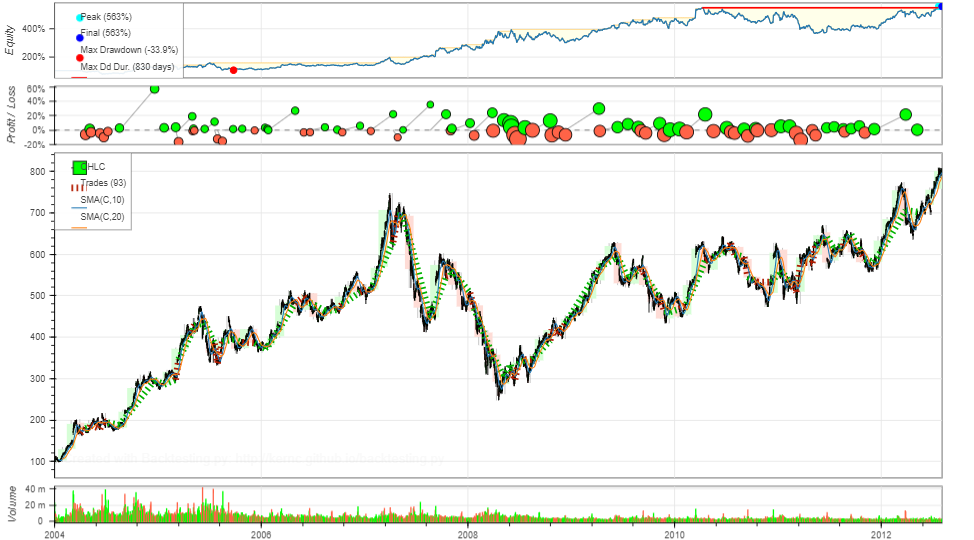